# Project setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "shared" / "config.py").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/sanjeet/ai_workspace/KWS model/sih-2026


# Load configuration

In [2]:
from shared.config import KEYWORD, MODELS_DIR
from shared.feature_spec import SPEC, FEATURE_SHAPE
from training.model import N_CLASSES

print(f"Keyword       : {KEYWORD}")
print(f"Feature shape : {FEATURE_SHAPE}")
print(f"Classes       : {N_CLASSES}")

I0000 00:00:1789840245.927289  165425 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Keyword       : marvin
Feature shape : (49, 20, 1)
Classes       : 3


# Locate the trained model

In [3]:
model_candidates = [
    MODELS_DIR / f"{KEYWORD}_best.keras",
    MODELS_DIR / f"{KEYWORD}.keras",
    MODELS_DIR / f"{KEYWORD}_final.keras",
]

model_path = next(
    (p for p in model_candidates if p.exists()),
    None,
)

if model_path is None:
    raise FileNotFoundError(
        f"No trained model found in {MODELS_DIR}"
    )

print(f"Using model: {model_path}")

Using model: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.keras


# Load model

In [4]:
import tensorflow as tf

model = tf.keras.models.load_model(
    model_path,
    compile=False,
)

model.summary()

W0000 00:00:1789840260.228350  165425 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "dscnn_s_residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc (InputLayer)   │ (None, 49, 20, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 25, 10,    │      2,560 │ mfcc[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 25, 10,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 25, 10,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pad          │ (None, 27, 12,    │          0 │ stem_relu[0][0]   │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_dwconv       │ (None, 25, 10,    │        576 │ block1_pad[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_dw_bn        │ (None, 25, 10,    │        256 │ block1_dwconv[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_dw_relu      │ (None, 25, 10,    │          0 │ block1_dw_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pwconv       │ (None, 25, 10,    │      4,096 │ block1_dw_relu[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pw_bn        │ (None, 25, 10,    │        256 │ block1_pwconv[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 25, 10,    │          0 │ block1_pw_bn[0][… │
│                     │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_out (ReLU)   │ (None, 25, 10,    │          0 │ block1_add[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pad          │ (None, 27, 12,    │          0 │ block1_out[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_dwconv       │ (None, 25, 10,    │        576 │ block2_pad[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_dw_bn        │ (None, 25, 10,    │        256 │ block2_dwconv[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_dw_relu      │ (None, 25, 10,    │          0 │ block2_dw_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pwconv       │ (None, 25, 10,    │      4,096 │ block2_dw_relu[0… │
│ (Conv2D)            │ 64)               │            │                 

 Total params: 23,747 (92.76 KB)

 Trainable params: 22,595 (88.26 KB)

 Non-trainable params: 1,152 (4.50 KB)

# Load current validation set

In [5]:
from training.train import collect

train_data, val_data, speakers, gsc_split = collect(
    KEYWORD,
    holdout_speaker=None,
    noise_cap=400,
)

x_val, y_val, _ = val_data.arrays()

print(f"Validation samples : {len(x_val)}")
print(f"Feature shape      : {x_val.shape[1:]}")
print(f"Using GSC test split: {gsc_split}")

  loaded 2000 clips...
  loaded 3000 clips...
  loaded 4000 clips...
  loaded 6000 clips...
  loaded 7000 clips...
  loaded 8000 clips...
  loaded 9000 clips...
  loaded 10000 clips...
  loaded 11000 clips...
  loaded 12000 clips...
  loaded 13000 clips...
  loaded 14000 clips...
  loaded 15000 clips...
  loaded 16000 clips...
  loaded 17000 clips...
  loaded 18000 clips...
  loaded 19000 clips...
  loaded 20000 clips...
  loaded 21000 clips...
  loaded 22000 clips...
  loaded 23000 clips...
Validation samples : 11164
Feature shape      : (49, 20, 1)
Using GSC test split: True


# Run inference

In [6]:
probs = model.predict(x_val, verbose=0)
y_pred = probs.argmax(axis=1)

print(f"Predictions shape: {probs.shape}")

W0000 00:00:1789840354.629971  165425 cpu_allocator_impl.cc:82] Allocation of 43762880 exceeds 10% of free system memory.


Predictions shape: (11164, 3)


# Confusion Matrix

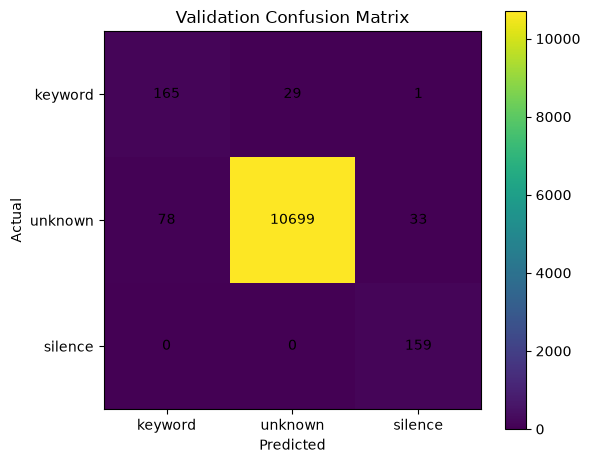

[[  165    29     1]
 [   78 10699    33]
 [    0     0   159]]


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["keyword", "unknown", "silence"]

cm = confusion_matrix(
    y_val,
    y_pred,
    labels=[0, 1, 2],
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Validation Confusion Matrix")

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(cm)

# TPR / FAR at current threshold

In [8]:
from training.train import wake_metrics, WAKE_SCORE_THRESHOLD

threshold = WAKE_SCORE_THRESHOLD

metrics = wake_metrics(
    probs,
    y_val,
    threshold,
)

print(f"Threshold     : {metrics['threshold']:.2f}")
print(f"TPR           : {metrics['tpr']:.4f} ({metrics['tpr']*100:.2f}%)")
print(f"FAR           : {metrics['far']:.4f} ({metrics['far']*100:.2f}%)")
print(f"False accepts : {metrics['false_accepts']}")
print(f"Keywords      : {metrics['n_keyword']}")
print(f"Negatives     : {metrics['n_negative']}")
print(f"FAR by class  : {metrics['far_by_class']}")

Threshold     : 0.52
TPR           : 0.8410 (84.10%)
FAR           : 0.0063 (0.63%)
False accepts : 69
Keywords      : 195
Negatives     : 10969
FAR by class  : {'unknown': 0.0064, 'silence': 0.0}


# Threshold Sweep

In [9]:
import numpy as np

thresholds = np.arange(0.30, 0.96, 0.05)

sweep = []

for threshold in thresholds:
    m = wake_metrics(probs, y_val, float(threshold))
    sweep.append({
        "threshold": threshold,
        "TPR": m["tpr"],
        "FAR": m["far"],
        "false_accepts": m["false_accepts"],
    })

for row in sweep:
    print(
        f"Threshold={row['threshold']:.2f}  "
        f"TPR={row['TPR']:.4f}  "
        f"FAR={row['FAR']:.4f}  "
        f"False accepts={row['false_accepts']}"
    )

Threshold=0.30  TPR=0.8667  FAR=0.0110  False accepts=121
Threshold=0.35  TPR=0.8667  FAR=0.0089  False accepts=98
Threshold=0.40  TPR=0.8667  FAR=0.0077  False accepts=85
Threshold=0.45  TPR=0.8564  FAR=0.0074  False accepts=81
Threshold=0.50  TPR=0.8462  FAR=0.0070  False accepts=77
Threshold=0.55  TPR=0.8256  FAR=0.0058  False accepts=64
Threshold=0.60  TPR=0.8154  FAR=0.0051  False accepts=56
Threshold=0.65  TPR=0.8103  FAR=0.0045  False accepts=49
Threshold=0.70  TPR=0.7949  FAR=0.0036  False accepts=39
Threshold=0.75  TPR=0.7897  FAR=0.0028  False accepts=31
Threshold=0.80  TPR=0.7436  FAR=0.0026  False accepts=29
Threshold=0.85  TPR=0.7282  FAR=0.0019  False accepts=21
Threshold=0.90  TPR=0.7077  FAR=0.0010  False accepts=11
Threshold=0.95  TPR=0.6769  FAR=0.0006  False accepts=7


# Plot threshold trade-off

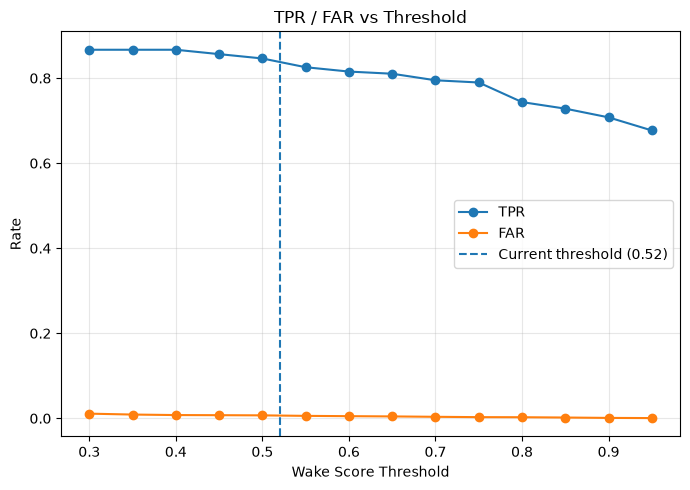

In [10]:
thresholds_plot = [r["threshold"] for r in sweep]
tpr_plot = [r["TPR"] for r in sweep]
far_plot = [r["FAR"] for r in sweep]

plt.figure(figsize=(7, 5))

plt.plot(thresholds_plot, tpr_plot, marker="o", label="TPR")
plt.plot(thresholds_plot, far_plot, marker="o", label="FAR")

plt.axvline(
    WAKE_SCORE_THRESHOLD,
    linestyle="--",
    label=f"Current threshold ({WAKE_SCORE_THRESHOLD:.2f})",
)

plt.xlabel("Wake Score Threshold")
plt.ylabel("Rate")
plt.title("TPR / FAR vs Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Final validation metrics

In [11]:
from sklearn.metrics import accuracy_score

final_metrics = {
    "accuracy": accuracy_score(y_val, y_pred),
    "tpr": metrics["tpr"],
    "far": metrics["far"],
    "false_accepts": metrics["false_accepts"],
    "threshold": metrics["threshold"],
}

print("=== Final Validation Metrics ===")
print(f"Accuracy       : {final_metrics['accuracy']:.4f}")
print(f"TPR            : {final_metrics['tpr']:.4f}")
print(f"FAR            : {final_metrics['far']:.4f}")
print(f"False accepts  : {final_metrics['false_accepts']}")
print(f"Threshold      : {final_metrics['threshold']:.2f}")

=== Final Validation Metrics ===
Accuracy       : 0.9874
TPR            : 0.8410
FAR            : 0.0063
False accepts  : 69
Threshold      : 0.52


In [14]:
import tensorflow as tf
from pathlib import Path

model_path = PROJECT_ROOT / "models" / "marvin.keras"
models_dir = PROJECT_ROOT / "models"

# ---------- FP16 ----------
fp16_converter = tf.lite.TFLiteConverter.from_keras_model(
    tf.keras.models.load_model(model_path, compile=False)
)

fp16_converter.optimizations = [tf.lite.Optimize.DEFAULT]
fp16_converter.target_spec.supported_types = [tf.float16]

fp16_model = fp16_converter.convert()

fp16_path = models_dir / "marvin.fp16.tflite"
fp16_path.write_bytes(fp16_model)


# ---------- INT8 ----------
int8_converter = tf.lite.TFLiteConverter.from_keras_model(
    tf.keras.models.load_model(model_path, compile=False)
)

int8_converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset for activation calibration
def representative_dataset():
    for i in range(min(len(x_val), 500)):
        yield [x_val[i:i+1].astype("float32")]

int8_converter.representative_dataset = representative_dataset

int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

int8_converter.inference_input_type = tf.int8
int8_converter.inference_output_type = tf.int8

int8_model = int8_converter.convert()

int8_path = models_dir / "marvin.int8.tflite"
int8_path.write_bytes(int8_model)


print(f"FP16: {fp16_path} — {len(fp16_model):,} bytes")
print(f"INT8: {int8_path} — {len(int8_model):,} bytes")

INFO:tensorflow:Assets written to: /tmp/tmp929it2ss/assets


INFO:tensorflow:Assets written to: /tmp/tmp929it2ss/assets


Saved artifact at '/tmp/tmp929it2ss'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 20, 1), dtype=tf.float32, name='mfcc')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  127815141209488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141210256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141211216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141210832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141211024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141209104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141210448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141210064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141211984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141211408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127815141209680: TensorS

W0000 00:00:1789841779.134872  165425 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789841779.134965  165425 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789841779.136373  165425 reader.cc:83] Reading SavedModel from: /tmp/tmp929it2ss
I0000 00:00:1789841779.139153  165425 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1789841779.139185  165425 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp929it2ss
I0000 00:00:1789841779.167176  165425 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1789841779.173320  165425 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1789841779.299066  165425 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp929it2ss
I0000 00:00:1789841779.335448  165425 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 199093 microseconds.
I0000 00:00:1789841779.416897  16542

INFO:tensorflow:Assets written to: /tmp/tmpcp5_hh6u/assets


INFO:tensorflow:Assets written to: /tmp/tmpcp5_hh6u/assets


Saved artifact at '/tmp/tmpcp5_hh6u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 20, 1), dtype=tf.float32, name='mfcc')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  127814950812368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950810640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950813520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950807952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950808720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950812176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950811024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950810832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950812560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950811792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127814950813136: TensorS

/home/sanjeet/ai_workspace/KWS model/sih-2026/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1789841780.475133  165425 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789841780.475195  165425 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789841780.475412  165425 reader.cc:83] Reading SavedModel from: /tmp/tmpcp5_hh6u
I0000 00:00:1789841780.478121  165425 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1789841780.478135  165425 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpcp5_hh6u
I0000 00:00:1789841780.507657  165425 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1789841780.638732  165425 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpcp5_hh6u
I0000 00:00:1789841780.672292  165425 loader.cc:471] 

FP16: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.fp16.tflite — 59,072 bytes
INT8: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.int8.tflite — 48,888 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1789841781.780487  165425 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
